In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/StudentsPerformance.csv")

In [3]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.gender.unique()

array(['female', 'male'], dtype=object)

In [7]:
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [8]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [9]:
df.lunch.unique()

array(['standard', 'free/reduced'], dtype=object)

In [10]:
df["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

In [11]:
df["math score"].unique()

array([ 72,  69,  90,  47,  76,  71,  88,  40,  64,  38,  58,  65,  78,
        50,  18,  46,  54,  66,  44,  74,  73,  67,  70,  62,  63,  56,
        97,  81,  75,  57,  55,  53,  59,  82,  77,  33,  52,   0,  79,
        39,  45,  60,  61,  41,  49,  30,  80,  42,  27,  43,  68,  85,
        98,  87,  51,  99,  84,  91,  83,  89,  22, 100,  96,  94,  48,
        35,  34,  86,  92,  37,  28,  24,  26,  95,  36,  29,  32,  93,
        19,  23,   8])

In [12]:
continuous=["math score","reading score","writing score"]
catagory=["gender","race/ethnicity","parental level of education","lunch","test preparation course"]

In [13]:
from sklearn.preprocessing import LabelEncoder
a=LabelEncoder()

In [14]:
for i in catagory:
  df[i]=a.fit_transform(df[i])

In [15]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75
...,...,...,...,...,...,...,...,...
995,0,4,3,1,0,88,99,95
996,1,2,2,0,1,62,55,55
997,0,2,2,0,0,59,71,65
998,0,3,4,1,0,68,78,77


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   int64
 1   race/ethnicity               1000 non-null   int64
 2   parental level of education  1000 non-null   int64
 3   lunch                        1000 non-null   int64
 4   test preparation course      1000 non-null   int64
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB


In [17]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [18]:
# correlation test

In [19]:
from scipy import stats

In [20]:
def correlation(d1,d2):
  corr,p_value=stats.pearsonr(d1,d2)
  if p_value<0.05:
    print("Reject null hypothesis")
  else:
    print("Accept null hypothesis")

In [22]:
correlation(df["math score"],df["reading score"])

Reject null hypothesis


In [23]:
# 2 sample ttest

In [24]:
def two_sample(d1,d2):
  f=0
  t=0
  t_test,p_value=stats.ttest_ind(d1,d2)
  if p_value<0.05:
    f=f+1
  else:
    t=t+1
  if f>t:
    return False
  else:
    return True

In [25]:
two_sample(df["math score"],df["writing score"])

False

In [26]:
#chisquare test catagory vs catagory

In [29]:
def chisquare(d1,d2):
  crosstab=pd.crosstab(d1,d2)
  f,p,dof,expected_val=stats.chi2_contingency(crosstab)
  if p<0.05:
    return True
  else:
    return False

In [30]:
chisquare(df["gender"],df["test preparation course"])

False

In [31]:
# annova test continuous vs catagory

In [33]:
def annova(d1,d2):
  group=df[d2].unique()
  data={}
  for i in group:
    data[i]=df[d1][df[d2]==i]
  f,p=stats.f_oneway(*[i for i in data.values()])
  if p<0.05:
    return False
  else:
    return True

In [35]:
annova("math score","gender")

False

In [36]:
# Visualization

In [37]:
#1. Distribution of Math Scores

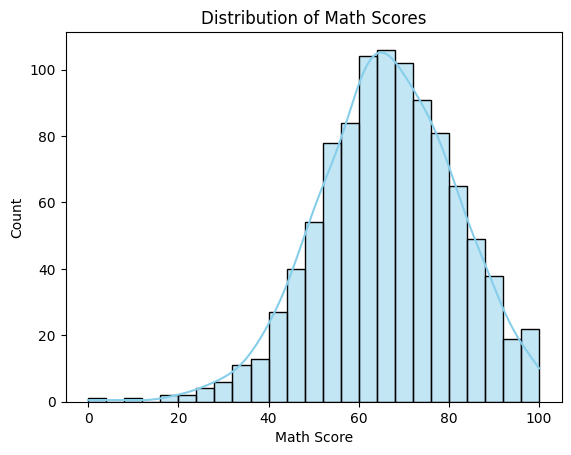

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["math score"], kde=True, color="skyblue")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()

In [39]:
#2. Barplot: Average Math Score by Parental Education


<ipython-input-42-564d96bd0162>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="parental level of education", y="math score", data=df, ci=None)


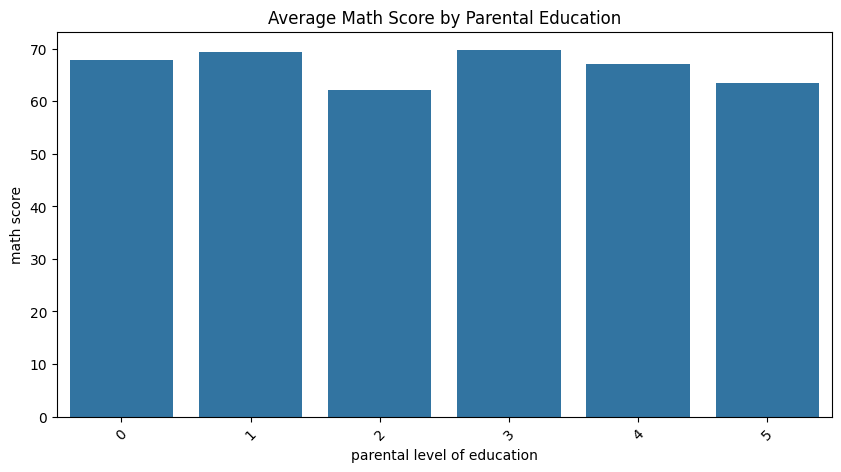

In [42]:
plt.figure(figsize=(10,5))
sns.barplot(x="parental level of education", y="math score", data=df, ci=None)
plt.title("Average Math Score by Parental Education")
plt.xticks(rotation=45)
plt.show()